# 05. Analysis & Paper — 결과 분석 + LLM-as-Judge + 논문 시각화
**산출물**: figures/*.png, M4 점수, 논문용 표·그림

**의존**: 04 결과(eval_summary.json), agent_extras.py

In [1]:
import json, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from config import (load_json, save_json, LLM_MODEL,
                    RESULTS_DIR, FIGURES_DIR, SCENARIO_DIR, SEVERITY_TABLE)

# ── 논문용 전역 설정 ──
for font in ['Malgun Gothic','AppleGothic','NanumGothic','sans-serif']:
    try: matplotlib.rcParams['font.family'] = font; break
    except: continue
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 150          # 화면 표시용
matplotlib.rcParams['savefig.dpi'] = 600          # ★ 저장 시 600 DPI
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 0         # 타이틀 비활성 (캡션 사용)
matplotlib.rcParams['legend.fontsize'] = 12       # ★ 범례 크게
matplotlib.rcParams['axes.labelsize'] = 12
PAPER_DIR = FIGURES_DIR / 'paper'
PAPER_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = RESULTS_DIR / 'tables'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── 데이터 로드 ──
eval_summary = load_json(RESULTS_DIR / 'evaluation' / 'eval_summary.json')
evals = eval_summary['evals']
N = eval_summary['n_scenarios']

results = {}
for skey in ['stage1','stage2','stage3','stage4']:
    path = RESULTS_DIR / skey / f'results_{N}scenarios.json'
    if path.exists():
        results[skey] = load_json(path)
        print(f'✅ {skey}: {len(results[skey])}건')
    else:
        print(f'⚠️ {skey}: 파일 없음')

scenarios = load_json(SCENARIO_DIR / 'scenarios_100.json')[:N]
print(f'✅ 시나리오: {len(scenarios)}건')

✅ stage1: 100건
✅ stage2: 100건
✅ stage3: 100건
✅ stage4: 100건
✅ 시나리오: 100건


## 1. 4-Stage Ablation 바 차트

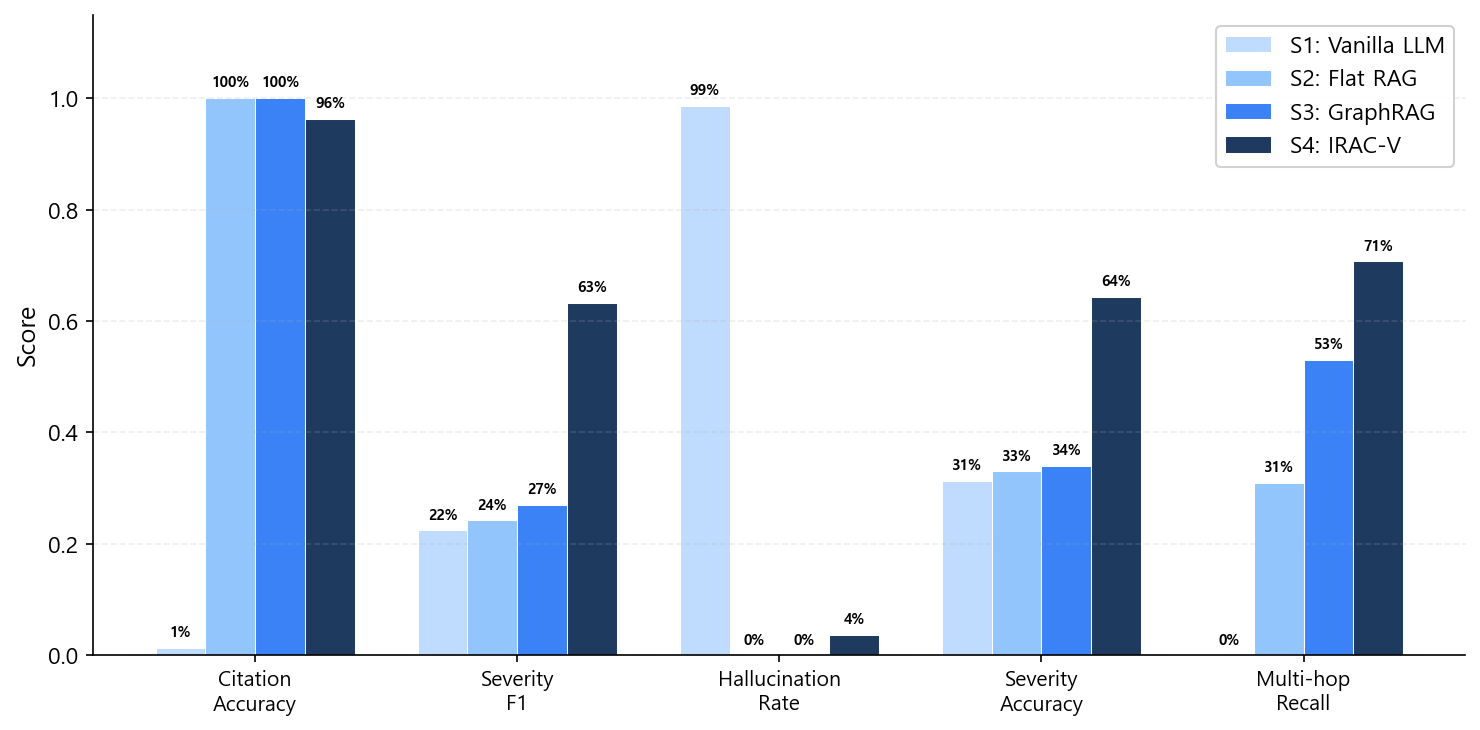

✅ figures\paper/figure1_ablation_comparison.png (600dpi)


In [2]:
# ══════════════════════════════════════════
# Figure 1: 4-Stage Ablation 성능 비교
# ══════════════════════════════════════════
metrics = ['M1_citation_accuracy','M3_severity_f1_macro','M5_hallucination_rate',
           'severity_accuracy','M6_multihop_recall']
labels = ['Citation\nAccuracy','Severity\nF1','Hallucination\nRate','Severity\nAccuracy','Multi-hop\nRecall']
stages = ['stage1','stage2','stage3','stage4']
stage_labels = ['S1: Vanilla LLM','S2: Flat RAG','S3: GraphRAG','S4: IRAC-V']
colors = ['#bfdbfe','#93c5fd','#3b82f6','#1e3a5f']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics)); w = 0.19
for j, (skey, slabel, color) in enumerate(zip(stages, stage_labels, colors)):
    vals = [evals[skey].get(m,0) for m in metrics]
    bars = ax.bar(x + j*w - 1.5*w, vals, w, label=slabel, color=color, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{v:.0%}', ha='center', fontsize=7, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11, loc='upper right', framealpha=0.9)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(PAPER_DIR / 'figure1_ablation_comparison.png')
plt.savefig(PAPER_DIR / 'figure1_ablation_comparison.pdf')  # 벡터 포맷
plt.show()
print(f'✅ {PAPER_DIR}/figure1_ablation_comparison.png (600dpi)')


## 2. 심각도 혼동 행렬 (Stage 4)

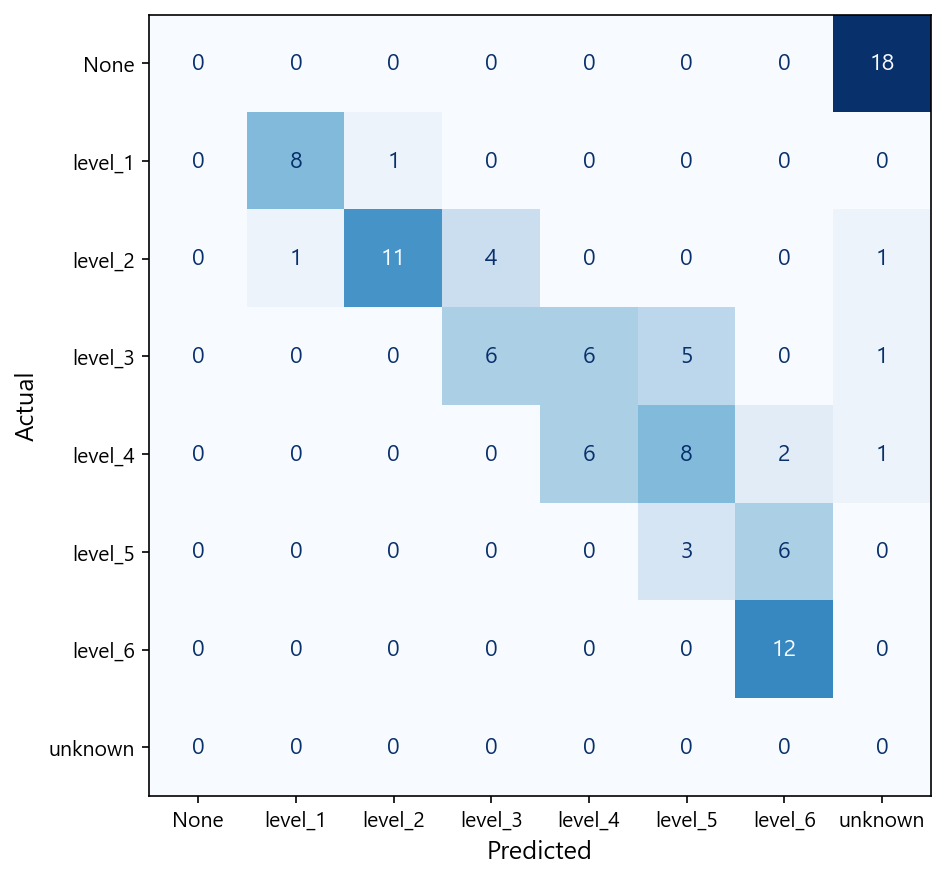

✅ figures\paper/figure2_confusion_matrix.png (600dpi)


In [3]:
# ══════════════════════════════════════════
# Figure 2: Stage 4 (IRAC-V) 심각도 혼동 행렬
# ══════════════════════════════════════════
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

if 'stage4' in results:
    y_true = [sc['expected'].get('severity_level') or 'None' for sc in scenarios]
    y_pred = [r.get('conclusion',{}).get('severity_level') or 'unknown' for r in results['stage4']]
    all_labels = sorted(set(y_true + y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.tick_params(axis='both', labelsize=10)
    plt.tight_layout()
    plt.savefig(PAPER_DIR / 'figure2_confusion_matrix.png')
    plt.savefig(PAPER_DIR / 'figure2_confusion_matrix.pdf')
    plt.show()
    print(f'✅ {PAPER_DIR}/figure2_confusion_matrix.png (600dpi)')


## 3. 카테고리별 정확도


=== Table 3: Category-wise Accuracy ===
             Category stage1 stage2 stage3 stage4
A_easy_explicit_limit   4/18   4/18   6/18  11/18
    B_medium_no_limit   2/18   3/18   3/18  10/18
     C_easy_non_speed  14/14  14/14  14/14  14/14
      D_hard_compound   4/14   4/14   4/14   9/14
   E_hard_aggravating   6/14   6/14   6/14   9/14
     F_medium_special   0/10   1/10   0/10   6/10
     G_hard_cross_law   1/12   1/12   1/12   5/12


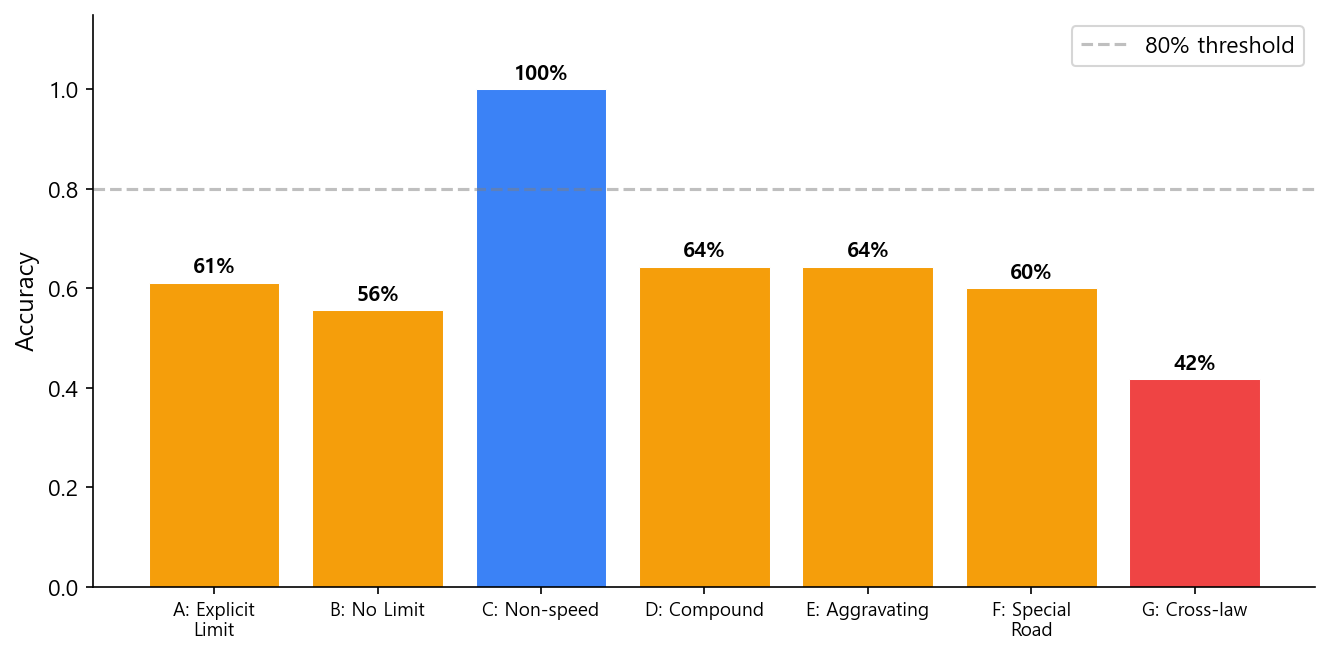

✅ figures\paper/figure3_category_accuracy.png (600dpi)
✅ results\tables/table3_category_accuracy.csv


In [4]:
# ══════════════════════════════════════════
# Figure 3 + Table 3: 카테고리별 정확도
# ══════════════════════════════════════════
if 'stage4' in results:
    def _norm(v):
        if v is None: return None
        s = str(v).strip().lower()
        return None if s in ('none','null','unknown','') else str(v)

    # 전 Stage 카테고리별 정확도 계산
    all_cat_stats = {}
    for skey in ['stage1','stage2','stage3','stage4']:
        if skey not in results: continue
        cat_stats = {}
        for r, sc in zip(results[skey], scenarios):
            cat = sc['category']
            if cat not in cat_stats: cat_stats[cat] = {'total':0,'correct':0}
            cat_stats[cat]['total'] += 1
            cat_stats[cat]['correct'] += int(_norm(r.get('conclusion',{}).get('severity_level',''))
                                              == _norm(sc['expected'].get('severity_level')))
        all_cat_stats[skey] = cat_stats

    # Table 3: CSV 저장
    cat_names = sorted(all_cat_stats.get('stage4',{}).keys())
    rows = []
    for cat in cat_names:
        row = {'Category': cat}
        for skey in ['stage1','stage2','stage3','stage4']:
            cs = all_cat_stats.get(skey,{}).get(cat,{})
            row[skey] = f"{cs.get('correct',0)}/{cs.get('total',0)}"
            row[f'{skey}_acc'] = cs['correct']/cs['total'] if cs.get('total',0) else 0
        rows.append(row)
    df_cat = pd.DataFrame(rows)
    df_cat.to_csv(TABLE_DIR / 'table3_category_accuracy.csv', index=False)
    print('\n=== Table 3: Category-wise Accuracy ===')
    print(df_cat[['Category','stage1','stage2','stage3','stage4']].to_string(index=False))

    # Figure 3: S4 카테고리별 바 차트
    cats = [c.split('_',1)[1] if '_' in c else c for c in cat_names]
    accs = [all_cat_stats['stage4'][c]['correct']/all_cat_stats['stage4'][c]['total'] for c in cat_names]
    cat_labels_short = ['A: Explicit\nLimit','B: No Limit','C: Non-speed',
                        'D: Compound','E: Aggravating','F: Special\nRoad','G: Cross-law']
    cat_labels_short = cat_labels_short[:len(cat_names)]

    fig, ax = plt.subplots(figsize=(9, 4.5))
    bar_colors = ['#3b82f6' if a >= 0.8 else '#f59e0b' if a >= 0.5 else '#ef4444' for a in accs]
    bars = ax.bar(range(len(cats)), accs, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(cats))); ax.set_xticklabels(cat_labels_short, fontsize=9)
    ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.15)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{acc:.0%}',
                ha='center', fontsize=10, fontweight='bold')
    ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
    ax.legend(fontsize=11); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(PAPER_DIR / 'figure3_category_accuracy.png')
    plt.savefig(PAPER_DIR / 'figure3_category_accuracy.pdf')
    plt.show()
    print(f'✅ {PAPER_DIR}/figure3_category_accuracy.png (600dpi)')
    print(f'✅ {TABLE_DIR}/table3_category_accuracy.csv')


## 4. ★ M4: Reasoning Quality — LLM-as-Judge 편향통제 (#6/#8)
Zheng et al. (2023) 프로토콜:
- 위치 편향: AB/BA 양방향 평가
- 자기강화 편향: 2종 프롬프트 변형 교대
- 3회 반복, 편차 > 1.0점 → 중간값

In [5]:
from agent_extras import evaluate_reasoning_quality_full

# LLM 호출 함수 준비 (04와 동일)
import anthropic
_client = anthropic.Anthropic(api_key=os.getenv('ANTHROPIC_API_KEY'))

def _call_llm_for_judge(prompt, system='', max_tokens=200, temperature=0.3):
    for attempt in range(3):
        try:
            msg = _client.messages.create(
                model=LLM_MODEL, max_tokens=max_tokens, temperature=temperature,
                system=system, messages=[{'role':'user','content':prompt}])
            return msg.content[0].text.replace('```json','').replace('```','').strip()
        except Exception as e:
            if 'rate' in str(e).lower(): time.sleep(5*(attempt+1))
            else: raise
    return '{"score":3,"justification":"LLM 호출 실패"}'

# ⚠️ API 비용 발생 — 먼저 10건으로 테스트, 이후 전체 실행
# 전체 실행 시 아래 주석 해제
M4_N = min(30, len(results.get('stage4',[])))  # ★ 10→30건 확대  # 먼저 10건 테스트

if 'stage4' in results and M4_N > 0:
    print(f'=== M4 Reasoning Quality 평가 ({M4_N}건) ===')
    print(f'편향통제: AB/BA 양방향 + 2종 프롬프트 + 3회 반복')

    rq = evaluate_reasoning_quality_full(
        results['stage4'][:M4_N],
        scenarios[:M4_N],
        _call_llm_for_judge,
        n_repeats=3,
        max_deviation=1.0
    )

    # 결과 저장
    evals['stage4']['M4_reasoning_quality'] = rq['mean']
    eval_summary['evals'] = evals
    eval_summary['M4_detail'] = rq
    save_json(eval_summary, RESULTS_DIR / 'evaluation' / 'eval_summary.json')

    print(f'\n✅ M4 결과: {rq["mean"]}/5.0 (std={rq["std"]}, n={rq["n_evaluated"]})')
    print(f'   편향통제: {rq["bias_control"]}')
else:
    print('⚠️ Stage 4 결과 없음 → M4 평가 스킵')

=== M4 Reasoning Quality 평가 (30건) ===
편향통제: AB/BA 양방향 + 2종 프롬프트 + 3회 반복
  M4 평가 진행: 10/30 (현재 평균: 3.55)
  M4 평가 진행: 20/30 (현재 평균: 3.74)
  M4 평가 진행: 30/30 (현재 평균: 3.59)

=== M4 Reasoning Quality ===
  평균: 3.59/5.0 (std=0.73)
  위치편향 불일치: 0건
  편차 초과: 8건
✅ 저장: results\evaluation\eval_summary.json

✅ M4 결과: 3.59/5.0 (std=0.73, n=30)
   편향통제: {'protocol': 'Zheng et al. (2023)', 'position_bias': 'AB/BA 양방향 평가, 불일치 0건', 'self_enhancement': '2종 프롬프트 변형(법학교수/전문심사자) 교대 사용', 'repetition': '3회 반복, 편차>1.0 → 중간값 (8건)'}


## 5. Self-Healing + API Fallback 분석

In [6]:
if 'stage4' in results:
    retries = [r.get('retries',0) for r in results['stage4']]
    undetermined = sum(1 for r in results['stage4'] if r.get('verification',{}).get('undetermined',False))
    api_used = sum(1 for r in results['stage4'] if r.get('api_fallback_used',False))

    print(f'=== Self-Healing 분석 ===')
    for i in range(4):
        print(f'  재시도 {i}회: {retries.count(i)}건')
    print(f'  Undetermined: {undetermined}건')
    print(f'  발동률: {sum(1 for r in retries if r>0)/max(len(retries),1):.1%}')

    print(f'\n=== API Fallback 분석 ===')
    print(f'  사용 건수: {api_used}건 / {len(results["stage4"])}건 ({api_used/max(len(results["stage4"]),1):.1%})')
    print(f'  총 API 호출: {eval_summary.get("api_fallback_total",0)}회')

=== Self-Healing 분석 ===
  재시도 0회: 97건
  재시도 1회: 0건
  재시도 2회: 3건
  재시도 3회: 0건
  Undetermined: 0건
  발동률: 3.0%

=== API Fallback 분석 ===
  사용 건수: 0건 / 100건 (0.0%)
  총 API 호출: 0회


## 6. 논문용 결과 테이블

In [7]:
# ══════════════════════════════════════════
# Table 1: 4-Stage Ablation Study Results
# ══════════════════════════════════════════
table1_rows = []
metric_list = [
    ('M1_citation_accuracy', 'Citation Accuracy'),
    ('M3_severity_f1_macro', 'Severity F1 (macro)'),
    ('M5_hallucination_rate', 'Hallucination Rate'),
    ('severity_accuracy', 'Severity Accuracy'),
    ('criminal_accuracy', 'Criminal Accuracy'),
    ('M6_multihop_recall', 'Multi-hop Recall'),
    ('avg_time_sec', 'Avg. Time (sec)'),
]
for m, label in metric_list:
    row = {'Metric': label}
    for s in stages:
        v = evals[s].get(m, 0)
        row[s] = f'{v:.1%}' if 'time' not in m else f'{v:.1f}'
    table1_rows.append(row)

df_t1 = pd.DataFrame(table1_rows)
df_t1.columns = ['Metric','S1: Vanilla','S2: Flat RAG','S3: GraphRAG','S4: IRAC-V']
df_t1.to_csv(TABLE_DIR / 'table1_ablation_results.csv', index=False)

print('\n=== Table 1: 4-Stage Ablation Study Results ===')
print(df_t1.to_string(index=False))

# Table 2: KG 효용 분석
print(f'\n=== Table 2: Knowledge Graph Utility (S2 → S3) ===')
table2_rows = []
for m, label in [('M3_severity_f1_macro','Severity F1'),
                  ('M1_citation_accuracy','Citation Accuracy'),
                  ('M6_multihop_recall','Multi-hop Recall'),
                  ('severity_accuracy','Severity Accuracy')]:
    s2v = evals['stage2'].get(m,0); s3v = evals['stage3'].get(m,0)
    table2_rows.append({'Metric':label, 'S2':f'{s2v:.1%}', 'S3':f'{s3v:.1%}',
                        'Delta':f'{s3v-s2v:+.1%}p'})
df_t2 = pd.DataFrame(table2_rows)
df_t2.to_csv(TABLE_DIR / 'table2_kg_utility.csv', index=False)
print(df_t2.to_string(index=False))
print(f'\n✅ {TABLE_DIR}/table1_ablation_results.csv')
print(f'✅ {TABLE_DIR}/table2_kg_utility.csv')



=== Table 1: 4-Stage Ablation Study Results ===
             Metric S1: Vanilla S2: Flat RAG S3: GraphRAG S4: IRAC-V
  Citation Accuracy        1.3%       100.0%       100.0%      96.3%
Severity F1 (macro)       22.4%        24.2%        27.1%      63.3%
 Hallucination Rate       98.7%         0.0%         0.0%       3.7%
  Severity Accuracy       31.3%        33.0%        34.0%      64.3%
  Criminal Accuracy       54.7%        55.0%        50.7%      75.7%
   Multi-hop Recall        0.0%        30.9%        53.0%      70.7%
    Avg. Time (sec)         6.4          6.7          7.4       11.7

=== Table 2: Knowledge Graph Utility (S2 → S3) ===
           Metric     S2     S3   Delta
      Severity F1  24.2%  27.1%  +2.8%p
Citation Accuracy 100.0% 100.0%  +0.0%p
 Multi-hop Recall  30.9%  53.0% +22.1%p
Severity Accuracy  33.0%  34.0%  +1.0%p

✅ results\tables/table1_ablation_results.csv
✅ results\tables/table2_kg_utility.csv


## ★ 통계적 유의성 검정
1. Bootstrap 95% 신뢰구간
2. McNemar's test (쌍별 비교)
3. S3 vs S3b vs S4 프롬프트 효과 분리

In [8]:
from scipy import stats
from sklearn.metrics import f1_score as _f1

def _norm(v):
    if v is None: return None
    s = str(v).strip().lower()
    return None if s in ('none','null','unknown','') else str(v)

# ── Bootstrap 95% CI ──
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000):
    n = len(y_true); scores = []
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        scores.append(metric_fn([y_true[i] for i in idx], [y_pred[i] for i in idx]))
    return round(np.mean(scores),4), round(np.percentile(scores,2.5),4), round(np.percentile(scores,97.5),4)

def sev_acc_fn(yt,yp): return sum(a==b for a,b in zip(yt,yp))/len(yt)
def sev_f1_fn(yt,yp): return _f1(yt,yp,average='macro',zero_division=0)

y_true = [str(_norm(sc['expected'].get('severity_level'))) for sc in scenarios]
stage_preds = {}
for skey in ['stage1','stage2','stage3','stage4']:
    if skey in results:
        stage_preds[skey] = [str(_norm(r.get('conclusion',{}).get('severity_level'))) for r in results[skey]]

print('=== Bootstrap 95% CI (n=1000) ===')
print(f'{"Stage":<8s} | {"Severity F1":>24s} | {"Severity Acc":>24s}')
print('-'*62)
ci_res = {}
for sk in ['stage1','stage2','stage3','stage4']:
    if sk not in stage_preds: continue
    f1m,f1l,f1h = bootstrap_ci(y_true, stage_preds[sk], sev_f1_fn)
    am,al,ah = bootstrap_ci(y_true, stage_preds[sk], sev_acc_fn)
    ci_res[sk] = {'f1':{'m':f1m,'lo':f1l,'hi':f1h},'acc':{'m':am,'lo':al,'hi':ah}}
    print(f'{sk:<8s} | {f1m:.1%} [{f1l:.1%}, {f1h:.1%}] | {am:.1%} [{al:.1%}, {ah:.1%}]')

# CI 겹침
print(f'\n=== CI 겹침 분석 ===')
pairs = [('stage1','stage2'),('stage2','stage3'),('stage3','stage4')]
for sa,sb in pairs:
    if sa not in ci_res or sb not in ci_res: continue
    a,b = ci_res[sa]['f1'],ci_res[sb]['f1']
    overlap = a['hi']>=b['lo'] and b['hi']>=a['lo']
    print(f'  {sa} vs {sb}: +{b["m"]-a["m"]:.1%}p, {"CI 겹침 ⚠️" if overlap else "CI 비겹침 → 유의 ✅"}')

# ── McNemar's test ──
print(f'\n=== McNemar test (α=0.05) ===')
for sa,sb in pairs:
    if sa not in stage_preds or sb not in stage_preds: continue
    ac = [yt==yp for yt,yp in zip(y_true,stage_preds[sa])]
    bc = [yt==yp for yt,yp in zip(y_true,stage_preds[sb])]
    b01 = sum(1 for a,b in zip(ac,bc) if not a and b)
    b10 = sum(1 for a,b in zip(ac,bc) if a and not b)
    n_disc = b01+b10
    if n_disc > 0:
        chi2 = (abs(b01-b10)-1)**2/(b01+b10)
        p = 1-stats.chi2.cdf(chi2,df=1)
    else: chi2,p = 0,1.0
    sig = '✅*' if p<0.05 else 'n.s.'
    print(f'  {sa} vs {sb}: χ²={chi2:.2f}, p={p:.4f} {sig} (A틀B맞={b01}, A맞B틀={b10})')

# Table 4: 통계 검정 결과 CSV
stat_rows = []
for sk in ['stage1','stage2','stage3','stage4']:
    if sk not in ci_res: continue
    stat_rows.append({
        'Stage': sk,
        'F1_mean': f"{ci_res[sk]['f1']['m']:.1%}",
        'F1_95CI': f"[{ci_res[sk]['f1']['lo']:.1%}, {ci_res[sk]['f1']['hi']:.1%}]",
        'Acc_mean': f"{ci_res[sk]['acc']['m']:.1%}",
        'Acc_95CI': f"[{ci_res[sk]['acc']['lo']:.1%}, {ci_res[sk]['acc']['hi']:.1%}]",
    })
df_t4 = pd.DataFrame(stat_rows)
df_t4.to_csv(TABLE_DIR / 'table4_statistical_tests.csv', index=False)
print(f'\n=== Table 4: Statistical Significance ===')
print(df_t4.to_string(index=False))

save_json({'bootstrap_ci':ci_res,'n_boot':1000},
          RESULTS_DIR/'evaluation'/'statistical_tests.json')
print(f'\n✅ {TABLE_DIR}/table4_statistical_tests.csv')


=== Bootstrap 95% CI (n=1000) ===
Stage    |              Severity F1 |             Severity Acc
--------------------------------------------------------------
stage1   | 21.8% [17.2%, 27.8%] | 31.0% [22.0%, 40.0%]
stage2   | 23.7% [18.3%, 30.3%] | 33.0% [24.0%, 43.0%]
stage3   | 26.6% [19.4%, 32.9%] | 33.9% [25.0%, 43.0%]
stage4   | 62.1% [53.9%, 70.4%] | 64.0% [55.0%, 74.0%]

=== CI 겹침 분석 ===
  stage1 vs stage2: +1.9%p, CI 겹침 ⚠️
  stage2 vs stage3: +2.9%p, CI 겹침 ⚠️
  stage3 vs stage4: +35.6%p, CI 비겹침 → 유의 ✅

=== McNemar test (α=0.05) ===
  stage1 vs stage2: χ²=0.50, p=0.4795 n.s. (A틀B맞=2, A맞B틀=0)
  stage2 vs stage3: χ²=0.00, p=1.0000 n.s. (A틀B맞=3, A맞B틀=2)
  stage3 vs stage4: χ²=28.03, p=0.0000 ✅* (A틀B맞=30, A맞B틀=0)

=== Table 4: Statistical Significance ===
 Stage F1_mean        F1_95CI Acc_mean       Acc_95CI
stage1   21.8% [17.2%, 27.8%]    31.0% [22.0%, 40.0%]
stage2   23.7% [18.3%, 30.3%]    33.0% [24.0%, 43.0%]
stage3   26.6% [19.4%, 32.9%]    33.9% [25.0%, 43.0%]
stage4   62.1% 

## 7. Stage별 시간 비교

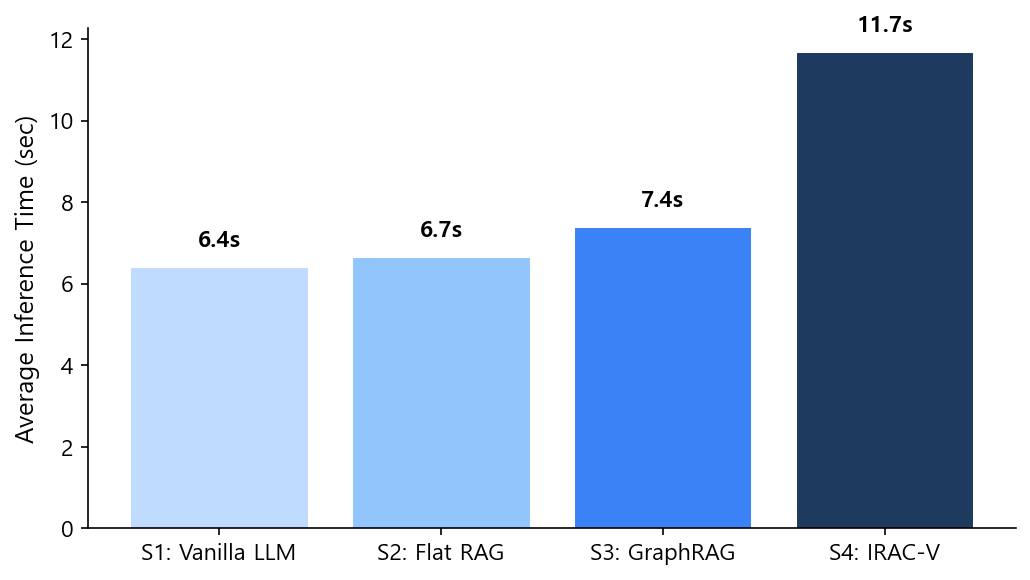

✅ figures\paper/figure4_inference_time.png (600dpi)


In [9]:
# ══════════════════════════════════════════
# Figure 4: Stage별 평균 추론 시간
# ══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 4))
stage_times = {s: evals[s].get('avg_time_sec',0) for s in stages}
bars = ax.bar(stage_labels, stage_times.values(), color=colors,
              edgecolor='white', linewidth=0.5)
ax.set_ylabel('Average Inference Time (sec)')
for j, v in enumerate(stage_times.values()):
    ax.text(j, v+0.5, f'{v:.1f}s', ha='center', fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(PAPER_DIR / 'figure4_inference_time.png')
plt.savefig(PAPER_DIR / 'figure4_inference_time.pdf')
plt.show()
print(f'✅ {PAPER_DIR}/figure4_inference_time.png (600dpi)')


## 8. 맵매칭 보고서 (논문 Limitation)

In [10]:
match_report_path = RESULTS_DIR / 'evaluation' / 'match_report.json'
if match_report_path.exists():
    mr = load_json(match_report_path)
    print(f'=== 제한속도 맵매칭 보고서 ===')
    print(f'  총 매칭: {mr.get("total",0)}건')
    print(f'  표지판 매칭: {mr.get("sign_matched",0)}건 ({mr.get("sign_rate",0):.1%})')
    print(f'  고속도로 매칭: {mr.get("highway_matched",0)}건 ({mr.get("highway_rate",0):.1%})')
    print(f'  법정속도 Fallback: {mr.get("statutory_fallback",0)}건 ({mr.get("statutory_rate",0):.1%})')
    print(f'  → 논문 Limitation에 매칭률 투명 보고 필요')
else:
    print('⚠️ match_report.json 없음 (02에서 맵매칭 미실행)')

=== 제한속도 맵매칭 보고서 ===
  총 매칭: 1100건
  표지판 매칭: 0건 (0.0%)
  고속도로 매칭: 0건 (0.0%)
  법정속도 Fallback: 1100건 (100.0%)
  → 논문 Limitation에 매칭률 투명 보고 필요


## 9. 최종 요약

In [11]:
# ══════════════════════════════════════════
# Table 5: RAG Retrieval Quality
# ══════════════════════════════════════════
rag_eval_path = RESULTS_DIR / 'evaluation' / 'rag_retrieval_quality.json'
if rag_eval_path.exists():
    rag_eval = load_json(rag_eval_path)
    print('=== Table 5: RAG Retrieval Quality ===')
    print(f'  Embedding Model: {rag_eval.get("embedding_model","?")}')
    print(f'  Corpus Size: {rag_eval.get("n_chunks","?")} chunks')
    print(f'  Test Queries: {rag_eval.get("n_tests","?")}건')
    print()
    for k, v in rag_eval.get('recall_at_k',{}).items():
        print(f'  {k}: {v:.1%}')
    
    # CSV 저장
    rows = []
    for r in rag_eval.get('per_query',[]):
        rows.append({'Category':r['category'],'Query':r['query'][:30],
                     'Required':','.join(r['required']),
                     'Found':','.join(r['found']),'Recall':f"{r['recall']:.0%}"})
    if rows:
        df_rag = pd.DataFrame(rows)
        df_rag.to_csv(TABLE_DIR / 'table5_rag_retrieval_quality.csv', index=False)
        print(f'\n✅ {TABLE_DIR}/table5_rag_retrieval_quality.csv')
else:
    print('⚠️ RAG 검색 품질 평가 결과 없음 (03 실행 필요)')


⚠️ RAG 검색 품질 평가 결과 없음 (03 실행 필요)


In [12]:
print('\n' + '='*60)
print('  연구 결과 최종 요약')
print('='*60)

s4 = evals['stage4']; s1 = evals['stage1']
s2 = evals.get('stage2',{}); s3 = evals.get('stage3',{})

print(f'\n[Stage 4: IRAC-V]')
print(f'  M1 Citation Acc:    {s4["M1_citation_accuracy"]:.1%} (vs S1: {s1["M1_citation_accuracy"]:.1%})')
print(f'  M3 Severity F1:    {s4["M3_severity_f1_macro"]:.3f} (vs S1: {s1["M3_severity_f1_macro"]:.3f})')
print(f'  M5 Hallucination:  {s4["M5_hallucination_rate"]:.1%} (vs S1: {s1["M5_hallucination_rate"]:.1%})')
m4 = s4.get('M4_reasoning_quality')
if m4: print(f'  M4 Reasoning:      {m4}/5.0')
m6 = s4.get('M6_multihop_recall',0)
print(f'  M6 Multi-hop:      {m6:.1%}')

if s2 and s3:
    # ★ v3: KG 효용 분석
    print(f'\n[KG 구조 효용 — S2→S3]')
    delta_f1 = s3.get('M3_severity_f1_macro',0) - s2.get('M3_severity_f1_macro',0)
    delta_mh = s3.get('M6_multihop_recall',0) - s2.get('M6_multihop_recall',0)
    delta_cite = s3.get('M1_citation_accuracy',0) - s2.get('M1_citation_accuracy',0)
    print(f'  Severity F1:    Δ={delta_f1:+.1%}p')
    print(f'  Multi-hop:      Δ={delta_mh:+.1%}p')
    print(f'  Citation Acc:   Δ={delta_cite:+.1%}p')

delta34 = s4.get('M3_severity_f1_macro',0) - s3.get('M3_severity_f1_macro',0)
print(f'\n[IRAC-V 효과]  S3→S4 Severity F1: +{delta34:.3f}')

print(f'\n→ paper_draft.md의 Table 수치를 위 결과로 치환하세요')
print('='*60)



  연구 결과 최종 요약

[Stage 4: IRAC-V]
  M1 Citation Acc:    96.3% (vs S1: 1.3%)
  M3 Severity F1:    0.633 (vs S1: 0.224)
  M5 Hallucination:  3.7% (vs S1: 98.7%)
  M4 Reasoning:      3.59/5.0
  M6 Multi-hop:      70.7%

[KG 구조 효용 — S2→S3]
  Severity F1:    Δ=+2.8%p
  Multi-hop:      Δ=+22.1%p
  Citation Acc:   Δ=+0.0%p

[IRAC-V 효과]  S3→S4 Severity F1: +0.362

→ paper_draft.md의 Table 수치를 위 결과로 치환하세요
